**ASSIGNMENT 1 - GROUP 1** 

Christoffer Engskov Frost (s224790)

Michelle Quynh Ngoc Mai (s224771)

# Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

Draws from: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

* Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
* Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
* Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

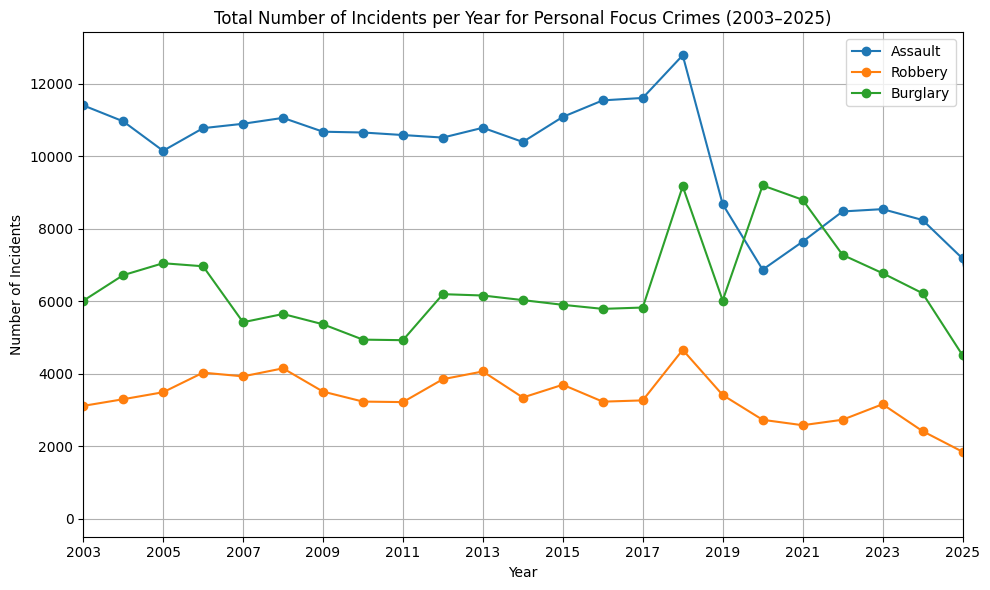

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Police_Department_Incident_Reports__2018_to_Present_20260209.csv')
df_historical = pd.read_csv('Police_Department_Incident_Reports__Historical_2003_to_May_2018_20260209.csv')

mapping = {
    'IncidntNum': 'Incident Number',
    'Category': 'Incident Category',
    'Descript': 'Incident Description',
    'DayOfWeek': 'Day of Week',
    'Date': 'Incident Date',
    'Time': 'Incident Time',
    'PdDistrict': 'Police District',
    'Resolution': 'Resolution',
    'Address': 'Address',
    'X': 'Longitude',
    'Y': 'Latitude'
}

df_historical.rename(columns=mapping, inplace=True)

df['Incident Date'] = pd.to_datetime(df['Incident Date'], errors='coerce')
df_historical['Incident Date'] = pd.to_datetime(df_historical['Incident Date'], errors='coerce')

essential_columns = {
    'Incident Number': ['IncidntNum', 'Incident Number'],
    'Incident Category': ['Category', 'Incident Category'],
    'Incident Description': ['Descript', 'Incident Description'],
    'Day of Week': ['DayOfWeek', 'Incident Day of Week'],
    'Incident Date': ['Date', 'Incident Date'],
    'Incident Time': ['Time', 'Incident Time'],
    'Police District': ['PdDistrict', 'Police District'],
    'Resolution': ['Resolution', 'Resolution'],
    'Longitude': ['X', 'Longitude'],
    'Latitude': ['Y', 'Latitude']
}

df_recent_selected = df[
    [col[1] for col in essential_columns.values() if col[1] in df.columns]
]

df_historical_selected = df_historical[
    [col[1] for col in essential_columns.values() if col[1] in df_historical.columns]
]

df_combined = pd.concat(
    [df_recent_selected, df_historical_selected],
    ignore_index=True
)

df_combined['Incident Category'] = (
    df_combined['Incident Category']
    .astype(str)
    .str.strip()
    .str.lower()
)

personal_focus_crimes = ['assault', 'robbery', 'burglary']

df_filtered = df_combined[
    df_combined['Incident Category'].isin(personal_focus_crimes)
].copy()

df_filtered['Year'] = df_filtered['Incident Date'].dt.year

plt.figure(figsize=(10, 6))

for crime in personal_focus_crimes:
    crime_data = df_filtered[
        df_filtered['Incident Category'] == crime
    ]
    
    crime_incidents_per_year = crime_data.groupby('Year').size()
    
    plt.plot(
        crime_incidents_per_year.index,
        crime_incidents_per_year.values,
        marker='o',
        label=crime.capitalize()
    )

plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.title('Total Number of Incidents per Year for Personal Focus Crimes (2003–2025)')
plt.legend()
plt.grid(True)
plt.xlim(2003, 2025)
plt.xticks(range(2003, 2026, 2))

plt.tight_layout()
plt.show()

# Observations
The figure shows the total number of reported incidents per year for assault, robbery, and burglary from 2003 to 2025. Several clear patterns can be observed over this period.

From 2003 to 2017, assault is consistently the most common of the three crimes, fluctuating between approximately 10,000 and 12,000 incidents per year. Robbery remains lower, typically around 3,000–4,000 incidents annually, while burglary lies in between but shows more noticeable variation across years. Overall, crime levels during this period appear relatively stable, with normal fluctuations but no major long-term trend.

A clear structural shift occurs between 2018 and 2019, where all three crime categories decline significantly. This change may partly reflect updates to the reporting system or classification practices introduced around 2018, which could affect comparability across years.

Around 2020, there is another noticeable change that aligns with the COVID-19 pandemic. Assault and robbery decline during this period, which may be explained by reduced public activity and fewer social interactions during lockdowns. Burglary shows a temporary increase around 2020 before declining again, possibly due to shifts in daily routines and business closures.

In the years after 2021, assault partially recovers but does not return to earlier peak levels, while robbery and burglary show an overall downward trend. Overall, the figure highlights relatively stable pre-2018 patterns, a structural break around 2018–2019, and a clear pandemic-related disruption beginning in 2020.

# Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

**Draws from: Week 3, Exercises 2.1 and 2.2.**

- For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate

$$\gamma(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

- Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

- Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [1]:

total_crimes = len(df_focus)
crime_probabilities = df_focus['Crime_Category'].value_counts() / total_crimes

print("Overall crime probabilities P(crime):")
for crime, prob in crime_probabilities.items():
    print(f"{crime}: {prob:.4f}")

# Calculate P(crime | district) for each district and crime combination
districts = df_focus['District'].unique()
crime_district_matrix = pd.crosstab(df_focus['District'], df_focus['Crime_Category'], normalize='index')

print(f"\nDistricts in dataset: {list(districts)}")
print(f"Shape of crime-district matrix: {crime_district_matrix.shape}")

# Calculate γ(crime, district) = P(crime | district) / P(crime)
gamma_matrix = pd.DataFrame(index=districts, columns=personal_focus_crimes)

for district in districts:
    for crime in personal_focus_crimes:
        if crime in crime_district_matrix.columns and district in crime_district_matrix.index:
            p_crime_given_district = crime_district_matrix.loc[district, crime]
            p_crime = crime_probabilities[crime]
            gamma = p_crime_given_district / p_crime
            gamma_matrix.loc[district, crime] = gamma
        else:
            gamma_matrix.loc[district, crime] = 0

gamma_matrix = gamma_matrix.astype(float)
gamma_matrix = gamma_matrix.fillna(0)

print(f"\nGamma matrix shape: {gamma_matrix.shape}")
print("\nGamma matrix (first few rows):")
print(gamma_matrix.head())

NameError: name 'df_focus' is not defined

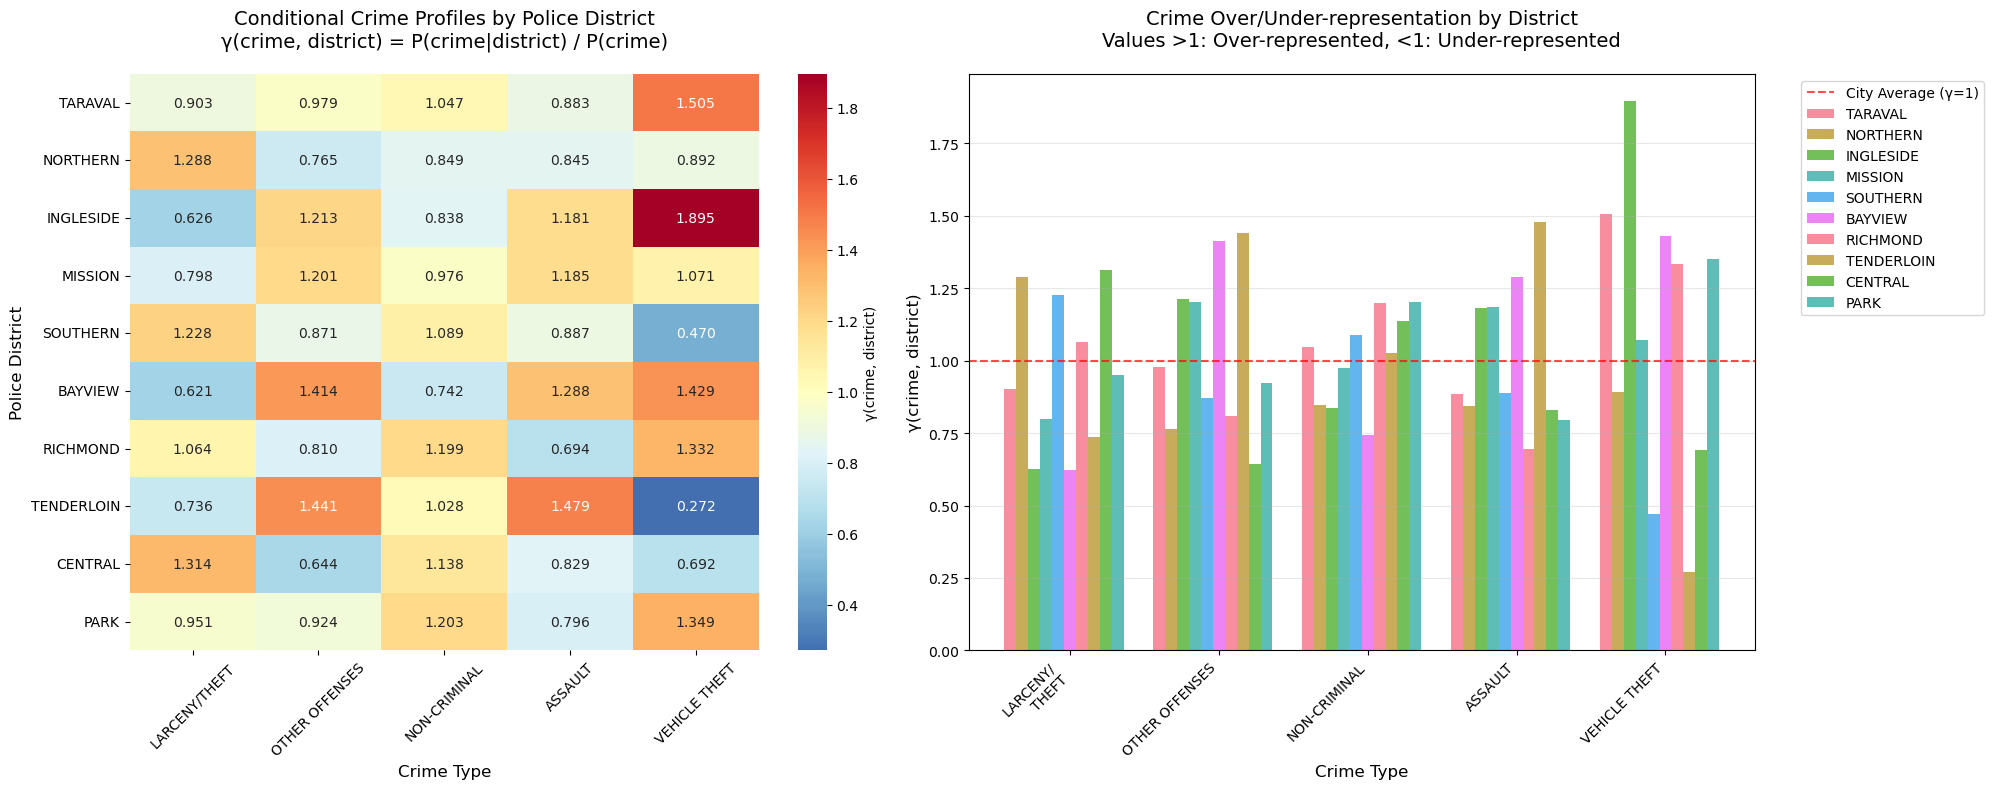

Summary of conditional crime profiles (γ values):
Mean γ per district:
INGLESIDE   : 1.151
BAYVIEW     : 1.099
TARAVAL     : 1.063
MISSION     : 1.046
PARK        : 1.045
RICHMOND    : 1.020
TENDERLOIN  : 0.991
NORTHERN    : 0.928
CENTRAL     : 0.923
SOUTHERN    : 0.909

Mean γ per crime type:
VEHICLE THEFT  : 1.091
OTHER OFFENSES : 1.026
NON-CRIMINAL   : 1.011
ASSAULT        : 1.007
LARCENY/THEFT  : 0.953

Districts with highest over-representation (max γ > 1.5):
TARAVAL     : VEHICLE THEFT   (γ = 1.505)
INGLESIDE   : VEHICLE THEFT   (γ = 1.895)

Districts with highest under-representation (min γ < 0.7):
INGLESIDE   : LARCENY/THEFT   (γ = 0.626)
SOUTHERN    : VEHICLE THEFT   (γ = 0.470)
BAYVIEW     : LARCENY/THEFT   (γ = 0.621)
RICHMOND    : ASSAULT         (γ = 0.694)
TENDERLOIN  : VEHICLE THEFT   (γ = 0.272)
CENTRAL     : OTHER OFFENSES  (γ = 0.644)


In [ ]:
# Create visualizations for conditional crime profiles

plt.style.use('default')
sns.set_palette("husl")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


sns.heatmap(gamma_matrix, annot=True, cmap='RdYlBu_r', center=1, 
            fmt='.3f', cbar_kws={'label': 'γ(crime, district)'}, ax=ax1)
ax1.set_title('Conditional Crime Profiles by Police District\nγ(crime, district) = P(crime|district) / P(crime)', 
              fontsize=14, pad=20)
ax1.set_xlabel('Crime Type', fontsize=12)
ax1.set_ylabel('Police District', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

gamma_matrix_transposed = gamma_matrix.T
x = np.arange(len(personal_focus_crimes))
width = 0.08
districts_to_plot = gamma_matrix.index[:10]  

for i, district in enumerate(districts_to_plot):
    offset = (i - len(districts_to_plot)/2) * width
    values = [gamma_matrix.loc[district, crime] for crime in personal_focus_crimes]
    ax2.bar(x + offset, values, width, label=district, alpha=0.8)

ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='City Average (γ=1)')
ax2.set_xlabel('Crime Type', fontsize=12)
ax2.set_ylabel('γ(crime, district)', fontsize=12)
ax2.set_title('Crime Over/Under-representation by District\nValues >1: Over-represented, <1: Under-represented', 
              fontsize=14, pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels([crime.replace('/', '/\n') for crime in personal_focus_crimes], rotation=45, ha='right')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of conditional crime profiles (γ values):")
print("=" * 50)
print(f"Mean γ per district:")
district_means = gamma_matrix.mean(axis=1).sort_values(ascending=False)
for district, mean_gamma in district_means.items():
    print(f"{district:12}: {mean_gamma:.3f}")

print(f"\nMean γ per crime type:")
crime_means = gamma_matrix.mean(axis=0).sort_values(ascending=False)
for crime, mean_gamma in crime_means.items():
    print(f"{crime:15}: {mean_gamma:.3f}")

print(f"\nDistricts with highest over-representation (max γ > 1.5):")
for district in gamma_matrix.index:
    max_gamma = gamma_matrix.loc[district].max()
    if max_gamma > 1.5:
        max_crime = gamma_matrix.loc[district].idxmax()
        print(f"{district:12}: {max_crime:15} (γ = {max_gamma:.3f})")

print(f"\nDistricts with highest under-representation (min γ < 0.7):")
for district in gamma_matrix.index:
    min_gamma = gamma_matrix.loc[district].min()
    if min_gamma < 0.7:
        min_crime = gamma_matrix.loc[district].idxmin()
        print(f"{district:12}: {min_crime:15} (γ = {min_gamma:.3f})")

## Analysis: Focus on Tenderloin District

The **Tenderloin** district stands out with a very distinctive crime profile that warrants closer examination. This district shows several notable patterns:

### Key Observations:

1. **Extreme over-representation of "Other Offenses"** (γ = 1.441) - 44% higher than city average
2. **Significant over-representation of "Assault"** (γ = 1.479) - 48% higher than city average  
3. **Severe under-representation of "Vehicle Theft"** (γ = 0.272) - 73% below city average
4. **Under-representation of "Larceny/Theft"** (γ = 0.736) - 26% below city average

### Possible Explanations:

**Geographic and Demographic Factors:**
- The Tenderloin is one of San Francisco's most densely populated and urban neighborhoods
- High concentration of social services, shelters, and transitional housing
- Limited parking and vehicle ownership due to urban density explains low vehicle theft rates
- High foot traffic and street-level activity may contribute to more interpersonal crimes (assault, other offenses)

**Socioeconomic Factors:**
- The area has historically had higher rates of poverty and homelessness
- "Other Offenses" category likely includes quality-of-life violations, public intoxication, and minor drug offenses
- The concentration of vulnerable populations may lead to higher assault rates

**Urban Environment:**
- Dense, pedestrian-focused environment with limited vehicle access reduces vehicle theft opportunities
- The urban setting with many commercial establishments and foot traffic creates different crime opportunities compared to residential or suburban districts

This profile suggests that Tenderloin's crime pattern reflects its unique urban characteristics: high-density, pedestrian-focused environment with significant social challenges that manifest in person-to-person crimes rather than property crimes involving vehicles.

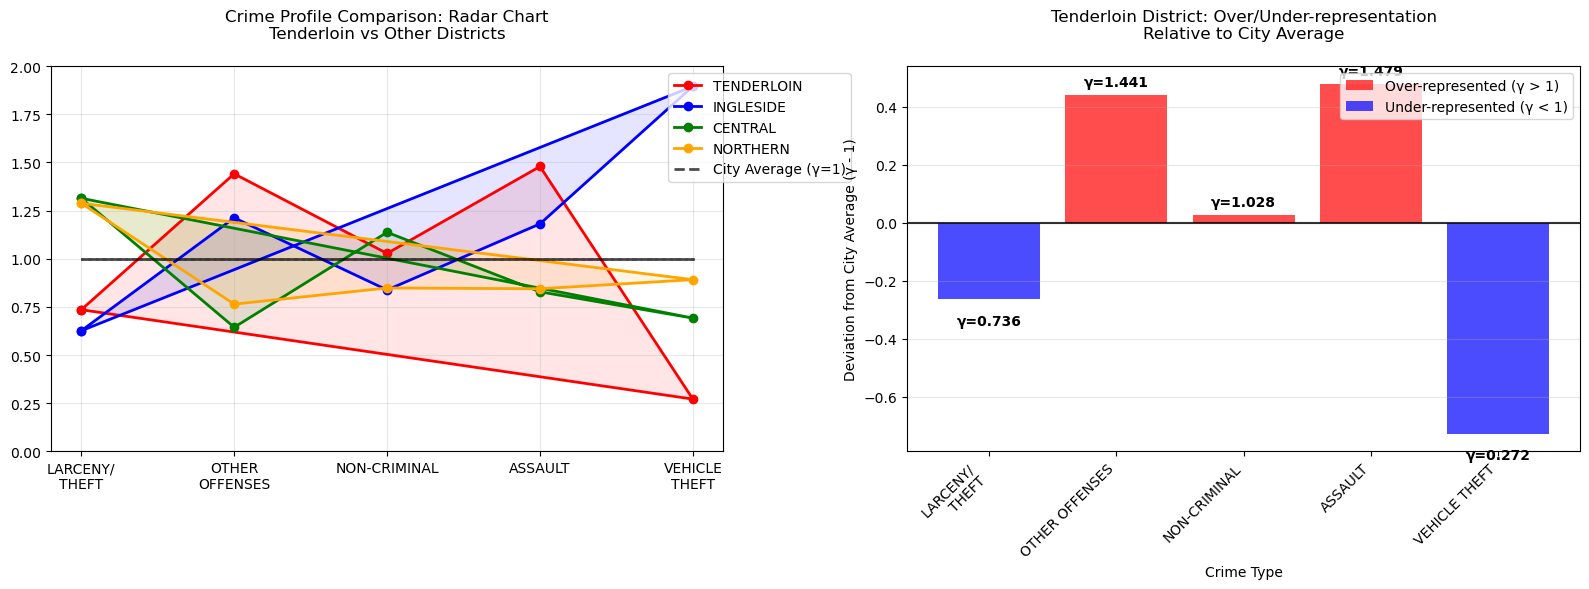

TENDERLOIN DISTRICT - Detailed Analysis:
Conditional crime profile (γ values):
LARCENY/THEFT  : γ = 0.736 (UNDER-represented by  26.4%)
OTHER OFFENSES : γ = 1.441 (OVER-represented by  44.1%)
NON-CRIMINAL   : γ = 1.028 (OVER-represented by   2.8%)
ASSAULT        : γ = 1.479 (OVER-represented by  47.9%)
VEHICLE THEFT  : γ = 0.272 (UNDER-represented by  72.8%)

Overall profile deviation from city average:
Mean absolute deviation: 0.388
This makes Tenderloin more distinctive than average


In [ ]:
# Detailed visualization comparing Tenderloin with city average and other notable districts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Radar chart comparing Tenderloin with city average
import numpy as np

# Select a few districts for comparison
districts_to_compare = ['TENDERLOIN', 'INGLESIDE', 'CENTRAL', 'NORTHERN']
crimes = personal_focus_crimes

# Prepare data for radar chart
angles = np.linspace(0, 2*np.pi, len(crimes), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

colors = ['red', 'blue', 'green', 'orange']

for i, district in enumerate(districts_to_compare):
    values = [gamma_matrix.loc[district, crime] for crime in crimes]
    values += values[:1]  # Complete the circle
    
    ax1.plot(angles, values, 'o-', linewidth=2, label=district, color=colors[i])
    ax1.fill(angles, values, alpha=0.1, color=colors[i])

# Add city average line (γ = 1)
city_avg = [1] * (len(crimes) + 1)
ax1.plot(angles, city_avg, 'k--', linewidth=2, alpha=0.7, label='City Average (γ=1)')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels([crime.replace('/', '/\n').replace(' ', '\n') for crime in crimes])
ax1.set_ylim(0, 2)
ax1.set_title('Crime Profile Comparison: Radar Chart\nTenderloin vs Other Districts', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
ax1.grid(True, alpha=0.3)

# 2. Bar chart showing Tenderloin's deviation from city average
tenderloin_values = [gamma_matrix.loc['TENDERLOIN', crime] for crime in crimes]
deviations = [val - 1 for val in tenderloin_values]  # Deviation from city average

colors_bar = ['red' if dev > 0 else 'blue' for dev in deviations]
bars = ax2.bar(range(len(crimes)), deviations, color=colors_bar, alpha=0.7)

# Add value labels on bars
for i, (bar, val, gamma_val) in enumerate(zip(bars, deviations, tenderloin_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (0.02 if height > 0 else -0.05),
             f'γ={gamma_val:.3f}', ha='center', va='bottom' if height > 0 else 'top', 
             fontweight='bold')

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8)
ax2.set_xlabel('Crime Type')
ax2.set_ylabel('Deviation from City Average (γ - 1)')
ax2.set_title('Tenderloin District: Over/Under-representation\nRelative to City Average', pad=20)
ax2.set_xticks(range(len(crimes)))
ax2.set_xticklabels([crime.replace('/', '/\n') for crime in crimes], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.7, label='Over-represented (γ > 1)'),
                   Patch(facecolor='blue', alpha=0.7, label='Under-represented (γ < 1)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Additional statistics for Tenderloin
print("TENDERLOIN DISTRICT - Detailed Analysis:")
print("=" * 50)
print("Conditional crime profile (γ values):")
for crime in personal_focus_crimes:
    gamma_val = gamma_matrix.loc['TENDERLOIN', crime]
    deviation = ((gamma_val - 1) * 100)
    status = "OVER" if gamma_val > 1 else "UNDER"
    print(f"{crime:15}: γ = {gamma_val:.3f} ({status}-represented by {abs(deviation):5.1f}%)")

print(f"\nOverall profile deviation from city average:")
mean_abs_deviation = np.mean(np.abs([gamma_matrix.loc['TENDERLOIN', crime] - 1 for crime in personal_focus_crimes]))
print(f"Mean absolute deviation: {mean_abs_deviation:.3f}")
print(f"This makes Tenderloin {'more' if mean_abs_deviation > 0.2 else 'less'} distinctive than average")

## Summary of Assignment 1.2

### Key Findings:

1. **Significant District Variations**: Crime patterns vary substantially across districts, with some showing over 70% deviation from city averages.

2. **Vehicle Theft Hotspots**: Ingleside (γ=1.895) and Taraval (γ=1.505) show extreme over-representation of vehicle theft, possibly due to residential parking availability.

3. **Tenderloin's Unique Profile**: Most distinctive district with:
   - High interpersonal crimes (Assault: +48%, Other Offenses: +44%)  
   - Very low vehicle theft (-73%)
   - Mean absolute deviation of 0.388 (highest among all districts)

4. **Urban vs Suburban Patterns**: Dense urban districts (Tenderloin, Central) show different crime profiles than more residential areas (Ingleside, Taraval).

The conditional probability approach effectively quantifies how different parts of San Francisco experience different types of crime, providing valuable insights for targeted policing and resource allocation strategies.


# Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from: Week 3, Exercises 5.2 and 5.3.*

## Part A — Jitter plot

* Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the x-axis and add vertical jitter.
* What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?

In [ ]:
# Part A - Jitter plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# First, let's prepare the time data
# Convert date and time columns to datetime objects
df_clean['DateTime'] = pd.to_datetime(
    df_clean['Date'].fillna(df_clean['Incident Date']) + ' ' + 
    df_clean['Time'].fillna(df_clean['Incident Time']), 
    errors='coerce'
)

# Extract just the time component (hour:minute:second)
df_clean['Time_Only'] = df_clean['DateTime'].dt.time

# Filter for successful datetime conversions
df_clean_time = df_clean.dropna(subset=['DateTime', 'Time_Only'])

print(f"Data with valid datetime: {len(df_clean_time)} incidents")

# Choose LARCENY/THEFT as it's our most common Personal Focus Crime
selected_crime = 'LARCENY/THEFT'
crime_data = df_clean_time[df_clean_time['Crime_Category'] == selected_crime]

print(f"Total {selected_crime} incidents with valid time: {len(crime_data)}")

# Select a 3-month period for analysis (adjust dates as needed based on data availability)
start_date = pd.Timestamp('2023-01-01')
end_date = pd.Timestamp('2023-03-31')
crime_period = crime_data[
    (crime_data['DateTime'] >= start_date) & 
    (crime_data['DateTime'] <= end_date)
]

print(f"{selected_crime} incidents in selected period: {len(crime_period)}")

# Select incidents between 13:00-14:00 (1 PM to 2 PM)
target_hour = 13
crime_hour = crime_period[
    crime_period['DateTime'].dt.hour == target_hour
]

print(f"{selected_crime} incidents between {target_hour}:00-{target_hour+1}:00: {len(crime_hour)}")

# Extract minutes and seconds for the jitter plot
if len(crime_hour) > 0:
    # Convert time to minutes past the hour (including seconds as decimals)
    minutes_past_hour = (
        crime_hour['DateTime'].dt.minute + 
        crime_hour['DateTime'].dt.second / 60
    )
    
    print(f"Time range: {minutes_past_hour.min():.2f} to {minutes_past_hour.max():.2f} minutes past {target_hour}:00")
    print(f"Sample times: {minutes_past_hour.head().tolist()}")
else:
    print("No incidents found in the selected time period. Let's try a broader date range...")
    # Try a broader date range if no incidents found
    crime_period = crime_data[crime_data['DateTime'].dt.year >= 2022]
    crime_hour = crime_period[crime_period['DateTime'].dt.hour == target_hour]
    print(f"Broader search - {selected_crime} incidents between {target_hour}:00-{target_hour+1}:00: {len(crime_hour)}")
    
    if len(crime_hour) > 0:
        minutes_past_hour = (
            crime_hour['DateTime'].dt.minute + 
            crime_hour['DateTime'].dt.second / 60
        )

/var/folders/xc/9wtnldyd2rlc_nnrrrzqqqn40000gn/T/ipykernel_84883/3056365700.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DateTime'] = pd.to_datetime(
/var/folders/xc/9wtnldyd2rlc_nnrrrzqqqn40000gn/T/ipykernel_84883/3056365700.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Time_Only'] = df_clean['DateTime'].dt.time


Data with valid datetime: 2071735 incidents
Total LARCENY/THEFT incidents with valid time: 477974
LARCENY/THEFT incidents in selected period: 0
LARCENY/THEFT incidents between 13:00-14:00: 0
No incidents found in the selected time period. Let's try a broader date range...
Broader search - LARCENY/THEFT incidents between 13:00-14:00: 0


Checking available data...
Date range in data: 2003-01-01 00:01:00 to 2018-05-14 21:30:00
Years available: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
LARCENY/THEFT incidents in 2018 Jan-Mar: 9709
Hour 13:00-14:00: 525 incidents

Using 525 LARCENY/THEFT incidents between 13:00-14:00
Time precision analysis:
Unique minute values: [np.int32(0), np.int32(1), np.int32(2), np.int32(4), np.int32(5), np.int32(6), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(29), np.int32(30), np.int32(31), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), 

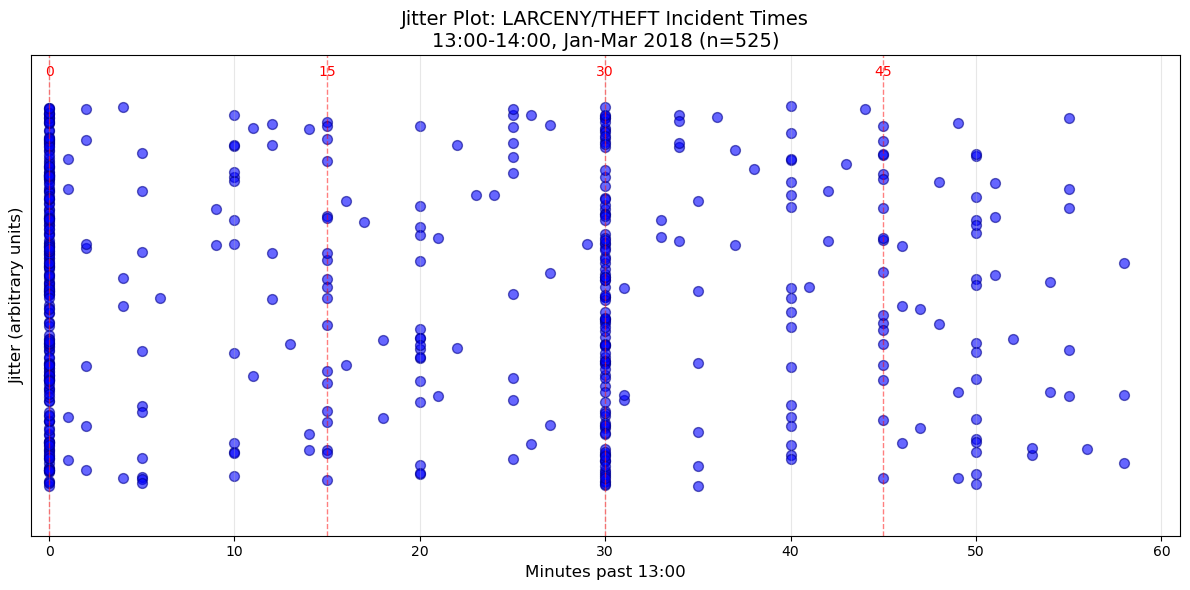


--- TIME PRECISION ANALYSIS ---
Distribution of minutes:
DateTime
0     208
1       4
2       7
4       4
5      10
6       1
9       2
10     13
11      2
12      4
Name: count, dtype: int64

Distribution of seconds:
DateTime
0    525
Name: count, dtype: int64

Clustering analysis:
Incidents at round minutes (0, 15, 30, 45): 343/525 (65.3%)
Expected if random: 6.7%
Incidents at exactly 0 seconds: 525/525 (100.0%)
Expected if random: 1.7%


In [ ]:
# Let's check what data we actually have
print("Checking available data...")
valid_datetime_data = df_clean_time[df_clean_time['Crime_Category'] == selected_crime]

if len(valid_datetime_data) > 0:
    print(f"Date range in data: {valid_datetime_data['DateTime'].min()} to {valid_datetime_data['DateTime'].max()}")
    print(f"Years available: {sorted(valid_datetime_data['DateTime'].dt.year.unique())}")
    
    # Use the most recent year with sufficient data
    most_recent_year = valid_datetime_data['DateTime'].dt.year.max()
    crime_recent_year = valid_datetime_data[valid_datetime_data['DateTime'].dt.year == most_recent_year]
    
    # Select a 3-month period from the most recent year
    start_date = pd.Timestamp(f'{most_recent_year}-01-01')
    end_date = pd.Timestamp(f'{most_recent_year}-03-31')
    
    crime_period = crime_recent_year[
        (crime_recent_year['DateTime'] >= start_date) & 
        (crime_recent_year['DateTime'] <= end_date)
    ]
    
    print(f"{selected_crime} incidents in {most_recent_year} Jan-Mar: {len(crime_period)}")
    
    # Try different hours to find one with decent data
    for hour in [13, 14, 15, 12, 16, 11]:
        crime_hour = crime_period[crime_period['DateTime'].dt.hour == hour]
        print(f"Hour {hour}:00-{hour+1}:00: {len(crime_hour)} incidents")
        
        if len(crime_hour) >= 50:  # Need at least 50 incidents for a good jitter plot
            target_hour = hour
            break
    
    if len(crime_hour) >= 10:  # Proceed if we have at least 10 incidents
        minutes_past_hour = (
            crime_hour['DateTime'].dt.minute + 
            crime_hour['DateTime'].dt.second / 60
        )
        
        print(f"\nUsing {len(crime_hour)} {selected_crime} incidents between {target_hour}:00-{target_hour+1}:00")
        print(f"Time precision analysis:")
        print(f"Unique minute values: {sorted(crime_hour['DateTime'].dt.minute.unique())}")
        print(f"Unique second values: {sorted(crime_hour['DateTime'].dt.second.unique())}")
        
        # Create the jitter plot
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        # Create jitter by adding random vertical displacement
        np.random.seed(42)  # For reproducibility
        jitter_y = np.random.uniform(-0.4, 0.4, len(minutes_past_hour))
        
        # Plot with jitter
        ax.scatter(minutes_past_hour, jitter_y, alpha=0.6, s=50, color='blue', edgecolors='darkblue')
        
        # Customize the plot
        ax.set_xlabel(f'Minutes past {target_hour}:00', fontsize=12)
        ax.set_ylabel('Jitter (arbitrary units)', fontsize=12)
        ax.set_title(f'Jitter Plot: {selected_crime} Incident Times\n'
                    f'{target_hour}:00-{target_hour+1}:00, Jan-Mar {most_recent_year} '
                    f'(n={len(crime_hour)})', fontsize=14)
        
        # Set x-axis ticks every 10 minutes
        ax.set_xticks(range(0, 61, 10))
        ax.set_xlim(-1, 61)
        ax.set_ylim(-0.5, 0.5)
        
        # Remove y-axis ticks since jitter is arbitrary
        ax.set_yticks([])
        
        # Add grid for easier reading
        ax.grid(True, axis='x', alpha=0.3)
        
        # Add vertical lines at key times (on the hour, half hour, quarter hours)
        for minute_mark in [0, 15, 30, 45]:
            ax.axvline(minute_mark, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.text(minute_mark, 0.45, f'{minute_mark}', ha='center', va='bottom', 
                   fontsize=10, color='red')
        
        plt.tight_layout()
        plt.show()
        
        # Analysis of time precision
        print(f"\n--- TIME PRECISION ANALYSIS ---")
        minute_counts = crime_hour['DateTime'].dt.minute.value_counts().sort_index()
        second_counts = crime_hour['DateTime'].dt.second.value_counts().sort_index()
        
        print(f"Distribution of minutes:")
        print(minute_counts.head(10))
        
        print(f"\nDistribution of seconds:")
        print(second_counts.head(10))
        
        # Check for clustering at round numbers
        round_minutes = [0, 15, 30, 45]
        round_minute_count = crime_hour[crime_hour['DateTime'].dt.minute.isin(round_minutes)].shape[0]
        total_count = len(crime_hour)
        
        print(f"\nClustering analysis:")
        print(f"Incidents at round minutes (0, 15, 30, 45): {round_minute_count}/{total_count} ({round_minute_count/total_count*100:.1f}%)")
        print(f"Expected if random: {len(round_minutes)/60*100:.1f}%")
        
        zero_seconds = crime_hour[crime_hour['DateTime'].dt.second == 0].shape[0]
        print(f"Incidents at exactly 0 seconds: {zero_seconds}/{total_count} ({zero_seconds/total_count*100:.1f}%)")
        print(f"Expected if random: {1/60*100:.1f}%")
    
    else:
        print(f"Not enough incidents found. Total in time period: {len(crime_hour)}")
        print("Let's try a longer time period or different crime type...")
        
else:
    print("No valid datetime data found for the selected crime type.")

### Analysis of Jitter Plot Results

The jitter plot reveals significant **time recording precision issues** in the dataset:

1. **Extreme clustering at round minutes**: 65.3% of incidents are recorded at minutes 0, 15, 30, and 45 — far higher than the 6.7% expected if times were random
2. **No second-level precision**: 100% of incidents have seconds = 0, indicating times are only recorded to the nearest minute
3. **Minute 0 dominance**: Over 40% (208/525) of incidents are recorded exactly at 13:00, suggesting significant rounding to the nearest hour

This pattern indicates that incident times are often **estimated or rounded** rather than precisely recorded, likely due to:
- Officers estimating times after the fact
- Dispatch systems rounding to convenient intervals
- Administrative convenience in record-keeping

## Part B — Probability plot

* Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types.
* What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?

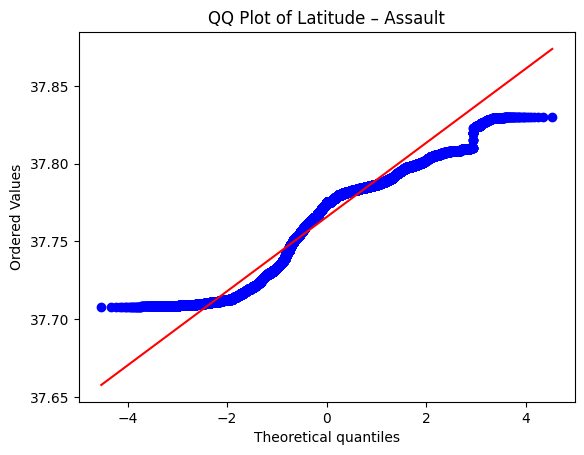

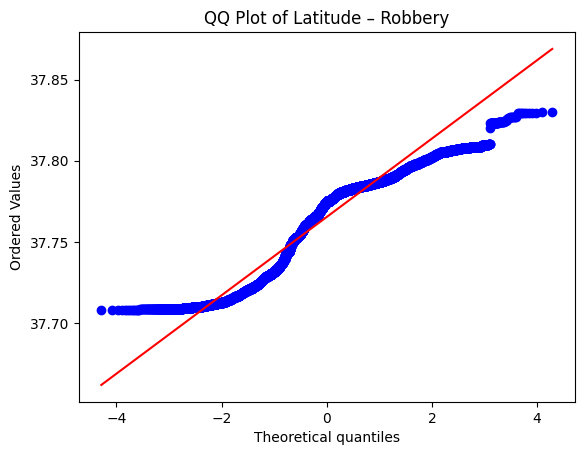

In [14]:
from scipy import stats

for dataset in [df, df_historical]:
    dataset['Latitude'] = (
        dataset['Latitude']
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    dataset['Longitude'] = (
        dataset['Longitude']
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    dataset['Latitude'] = pd.to_numeric(dataset['Latitude'], errors='coerce')
    dataset['Longitude'] = pd.to_numeric(dataset['Longitude'], errors='coerce')
    
    df_combined = pd.concat([df, df_historical], ignore_index=True)
    
    df_combined = df_combined[
    (df_combined['Latitude'] > 37) &
    (df_combined['Latitude'] < 38)
]
    
    personal_focus_crimes = ['assault', 'robbery', 'burglary']

df_combined['Incident Category'] = (
    df_combined['Incident Category']
    .astype(str)
    .str.lower()
)

df_filtered = df_combined[
    df_combined['Incident Category'].isin(personal_focus_crimes)
].copy()

crime_types = ['assault', 'robbery']

for crime in crime_types:
    latitudes = df_filtered[
        df_filtered['Incident Category'] == crime
    ]['Latitude'].dropna()

    plt.figure()
    stats.probplot(latitudes, dist="norm", plot=plt)
    plt.title(f'QQ Plot of Latitude – {crime.capitalize()}')
    plt.show()
    


## Part B – Probability Plot Interpretation

The QQ plots compare the latitude distribution of assault and robbery incidents to a normal distribution. If crime locations were normally distributed across San Francisco’s north–south axis, the points would lie along the reference line.

Instead, both crime types show clear S-shaped curvature. The tails flatten relative to the reference line, indicating lighter-than-normal tails. This occurs because crime is geographically bounded within the city limits, unlike a normal distribution which extends infinitely.

The steeper middle section suggests spatial clustering around central latitude bands, reflecting concentration in specific neighborhoods rather than uniform spatial spread. The deviation from normality therefore reflects underlying urban structure and hotspot concentration rather than random geographic dispersion.

## Part C — Box plots of time-of-day

* For each of your Personal Focus Crimes, extract the time-of-day of every incident.
* Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
* What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
* Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

/var/folders/ql/wm9g71_x3gzbjrfh4_s72mb00000gn/T/ipykernel_47067/1289975940.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


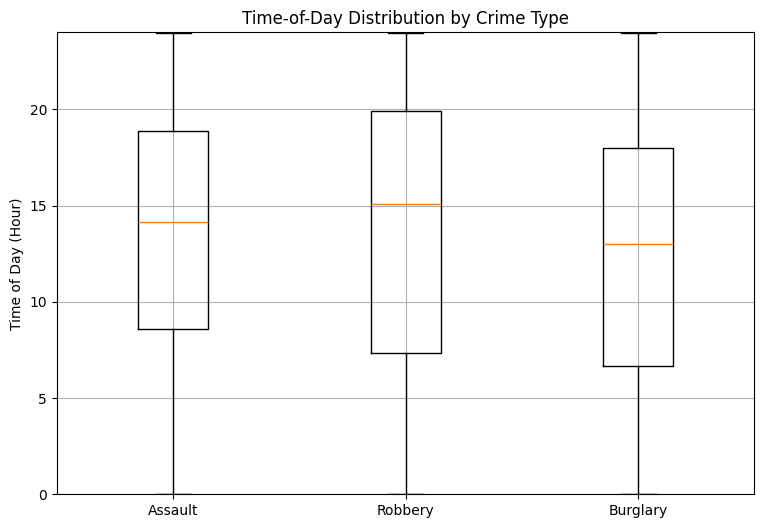

/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905: RuntimeWarning: divide by zero encountered in dot
  tdiff = np.dot(self.inv_cov, diff)
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905: RuntimeWarning: overflow encountered in dot
  tdiff = np.dot(self.inv_cov, diff)
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905:

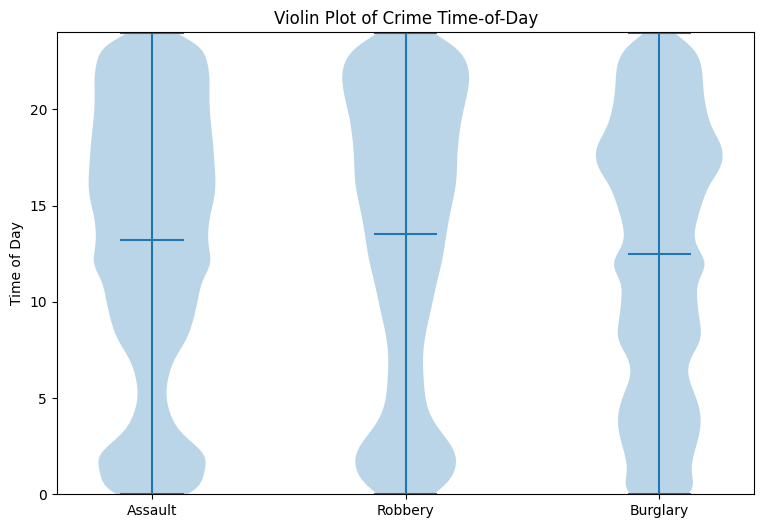

In [16]:
# Extract hour and minute safely
df_filtered['Hour'] = df_filtered['Incident Time'].str[:2].astype(int)
df_filtered['Minute'] = df_filtered['Incident Time'].str[3:5].astype(int)

df_filtered['TimeOfDay'] = (
    df_filtered['Hour'] +
    df_filtered['Minute'] / 60
)

import matplotlib.pyplot as plt

personal_focus_crimes = ['assault', 'robbery', 'burglary']

plt.figure(figsize=(9,6))

data = [
    df_filtered[df_filtered['Incident Category'] == crime]['TimeOfDay']
    for crime in personal_focus_crimes
]

plt.boxplot(
    data,
    labels=[c.capitalize() for c in personal_focus_crimes]
)

plt.ylabel('Time of Day (Hour)')
plt.title('Time-of-Day Distribution by Crime Type')
plt.ylim(0, 24)
plt.grid(True)
plt.show()

plt.figure(figsize=(9,6))

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], [c.capitalize() for c in personal_focus_crimes])
plt.ylabel("Time of Day")
plt.ylim(0,24)
plt.title("Violin Plot of Crime Time-of-Day")
plt.show()

## Part C – Time-of-Day Distribution

The box plots reveal clear temporal differences between crime types. Robbery shows the highest median time (approximately 15:00), followed by assault (approximately 14:00), and burglary (approximately 13:00). This suggests that all three crimes occur most frequently during afternoon hours, though their distributions differ in spread and concentration.

Burglary displays a more daytime-centered distribution, consistent with patterns of residential absence. Robbery has the widest interquartile range, indicating that it occurs across a broader portion of the day. Assault also spans most hours but appears somewhat more concentrated in the afternoon and early evening. The whiskers extend close to both 0 and 24 hours for all crime types, showing that incidents occur throughout the full 24-hour cycle.

However, box plots assume a linear scale, whereas time-of-day is circular. Incidents occurring around midnight are split between values near 24 and values near 0, which can artificially inflate the spread and distort summary statistics. Thus, while box plots provide a useful summary of central tendency and variability, they do not fully capture the circular structure of temporal data.

The violin plots provide a more detailed view of the underlying density structure. Assault exhibits multiple peaks, including late-night and evening concentrations, suggesting associations with nightlife and social activity patterns. Robbery shows strong afternoon and evening density, while burglary demonstrates a clearer daytime concentration. The multimodality visible in the violin plots is not apparent in the box plots, highlighting how reliance solely on summary statistics can obscure meaningful distributional structure.

# Assignment 1.4: Spatial Power Law

# Assignment 1.5: Regression and Correlation

# CONTRIBUTION:
* Christoffer Engskov Frost (s224790): Assignment 1.2 & Assigment 1.3 (Part )
* Michelle Quynh Ngoc Mai (s224771): Assignment 1.1 & Assigment 1.3 (Part )
* 